# Analisi Qualita' Dati RTP x Supporto GO-LIVE (Tassonomie,Date Scadenza)

Questo notebook esegue una serie di passaggi per identificare la qualità di alcuni campi delle posizioni debitorie GPD.

# Perimetro Dati in analisi
1) Posizioni Debitorie su GPD e ACA (no paCreatePosition)
2) Posizioni Debitore "VALID"
3) Periodo temporale 01/01/2026 -> oggi

In [1]:
import cml.data_v1 as cmldata

In [2]:
CONNECTION_NAME = "dl-analysis-impala-vw"
conn = cmldata.get_connection(CONNECTION_NAME)

In [3]:
## Sample Usage to get pandas data frame
QUERY = """
select t.after.category as category, po.after.description as description, pp.after.id as id, pp.after.iupd as iupd, po.after.due_date as due_date, pp.after.company_name as company_name
from pagopa.bronze_gpd_payment_position pp
INNER JOIN pagopa.bronze_gpd_payment_option po ON pp.after.id = po.after.payment_position_id
INNER JOIN pagopa.bronze_gpd_transfer t ON t.after.payment_option_id = po.after.id
WHERE 
pp.after.inserted_date is not null
and pp.after.inserted_date BETWEEN unix_timestamp('2026-03-01 00:00:01')*1000000 AND unix_timestamp('2026-03-31 00:00:00')*1000000  
and pp.after.status in ('VALID')
and pp.after.iupd not like 'ACA_%' and pp.after.service_type in ('GPD','ACA')
"""

dataframe = conn.get_pandas_dataframe(QUERY)
# Closing the connection
conn.close()

In [4]:
import pandas as pd
import re
import requests
import io
import csv

# --- 1. CARICAMENTO TASSONOMIA (METODO ULTRA-ROBUSTO) ---
url_taxonomy = "https://api.platform.pagopa.it/taxonomy/service/v1/taxonomy?extension=csv"
col_ref = 'dati_specifici_di_incasso'

try:
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url_taxonomy, headers=headers)
    response.raise_for_status()
    
    f = io.StringIO(response.text)
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    header = [h.replace('"', '').strip() for h in header]
    col_idx = header.index(col_ref)
    
    valid_codes_list = []
    scarti_csv = [] 

    for i, row in enumerate(reader, start=2):
        if len(row) > col_idx:
            raw_code = row[col_idx].replace('"', '').strip()
            if re.match(r'^[6-9]/', raw_code):
                valid_codes_list.append(raw_code)
            else:
                scarti_csv.append({
                    'riga_csv': i,
                    'valore_trovato': raw_code,
                    'note': 'Formato non valido'
                })
        else:
            scarti_csv.append({
                'riga_csv': i,
                'valore_trovato': 'N/D',
                'note': 'Colonna mancante'
            })

    valid_codes_set = set(valid_codes_list)
    
    print(f"--- ANALISI FILE CSV (via URL) ---")
    print(f"Record totali processati:     {len(valid_codes_list) + len(scarti_csv)}")
    print(f"Codici univoci (validi):      {len(valid_codes_set)}")

except Exception as e:
    print(f"❌ Errore nel caricamento della tassonomia: {e}")
    valid_codes_set = set()


# --- 2. VALIDAZIONE SUL TUO DATAFRAME ---

taxonomic_regex = r'^(9|6|7|8)\/\d{7}(IM|TS|SP|SA|AP)\/?$'
secondary_regex = r'^\d{7}(IM|TS|SP|SA|AP)$'

if 'category' in dataframe.columns:

    # Normalizzazione
    dataframe['category_clean'] = (
        dataframe['category']
        .astype(str)
        .str.replace('"', '')
        .str.strip()
    )

    # A. Validazione Sintattica Principale
    dataframe['is_syntax_correct'] = dataframe['category_clean'].str.match(
        taxonomic_regex, na=False
    )

    # B. Validazione Sintattica Alternativa (7 cifre + suffisso)
    dataframe['is_secondary_syntax'] = dataframe['category_clean'].str.match(
        secondary_regex, na=False
    )

    # C. Validazione Semantica
    dataframe['is_semantically_correct'] = dataframe['category_clean'].isin(valid_codes_set)

    # D. Prefissi specifici (6/7/8)
    dataframe['is_specific_prefix'] = (
        dataframe['is_semantically_correct'] &
        dataframe['category_clean'].str.match(r'^[6-8]/', na=False)
    )

    # --- 3. REPORT GENERALE ---
    total_records = len(dataframe)
    syntax_ok = dataframe['is_syntax_correct'].sum()
    syntax_ko = total_records - syntax_ok

    semantic_ok = dataframe['is_semantically_correct'].sum()
    specific_prefix_ok = dataframe['is_specific_prefix'].sum()

    # --- SOTTO-ANALISI DEI SINTASSI ERRATI ---
    syntax_ko_df = dataframe[~dataframe['is_syntax_correct']]
    secondary_ok = syntax_ko_df['is_secondary_syntax'].sum()
    secondary_ko = syntax_ko - secondary_ok

    print("\n" + "="*95)
    print("📊 REPORT GENERALE ANALISI CODICI TASSONOMICI")
    print("="*95)
    print(f"Totale record analizzati:      {total_records}")
    print(f"1) Rispettano la sintassi:     {syntax_ok} ✅")
    print(f"2) NON rispettano la sintassi: {syntax_ko} ❌")
    print(f"   2.1) Rispettano sintassi alternativa (7 cifre + suffisso): {secondary_ok}")
    print(f"   2.2) NON rispettano neanche la sintassi alternativa:       {secondary_ko}")
    
    if syntax_ko > 0:
        print(f"\n% errori recuperabili con sola aggiunta prefisso: {secondary_ok / syntax_ko:.2%}")

    print(f"\n3) Semanticamente corretti:    {semantic_ok} 🏛️")
    print(f"4) Prefissi Specifici (6/7/8): {specific_prefix_ok} 🏷️")
    print("-" * 95)


    # --- 4. ESEMPI REALI ---
    print("\nDETTAGLIO ESEMPI REALI:")
    casistiche = [
        ("✅ Sintassi OK", dataframe[dataframe['is_syntax_correct']]),
        ("❌ Sintassi Errata", dataframe[~dataframe['is_syntax_correct']]),
        ("🔄 Sintassi Alternativa", dataframe[dataframe['is_secondary_syntax']]),
        ("🏛️ Semantica OK", dataframe[dataframe['is_semantically_correct']]),
        ("🏷️ Prefisso 6/7/8", dataframe[dataframe['is_specific_prefix']])
    ]

    for label, df_sub in casistiche:
        if not df_sub.empty:
            row = df_sub.iloc[0]
            print(f"{label:25} -> Codice: {row['category']:15} | ID: {row['id']:15} | IUPD: {row['iupd']}")
        else:
            print(f"{label:25} -> Nessun record trovato")


    # --- 5. RAGGRUPPAMENTO PER COMPANY_NAME ---
    if 'company_name' in dataframe.columns:
        stats_company = dataframe.groupby('company_name').agg(
            Sintassi_OK=('is_syntax_correct', 'sum'),
            Sintassi_Alt=('is_secondary_syntax', 'sum'),
            Semantica_OK=('is_semantically_correct', 'sum'),
            Prefissi_678=('is_specific_prefix', 'sum'),
            Totale_Record=('category', 'count')
        )

        stats_company['Sintassi_KO'] = stats_company['Totale_Record'] - stats_company['Sintassi_OK']

        stats_company = stats_company[
            ['Sintassi_OK', 'Sintassi_KO', 'Sintassi_Alt',
             'Semantica_OK', 'Prefissi_678', 'Totale_Record']
        ]

        top_50 = stats_company.sort_values(
            by='Totale_Record',
            ascending=False
        ).head(50)

        print("\n" + "="*95)
        print("🏢 STATISTICHE PER COMPANY (Top 50 per volume)")
        print("="*95)
        display(top_50)

        # --- FOCUS DETTAGLIATO PER COMPANY ---
        for company in top_50.index:
            print(f"\n🔍 FOCUS AZIENDA: {company}")
            df_comp = dataframe[dataframe['company_name'] == company]

            casistiche_comp = [
                ("✅ Sintassi OK", df_comp[df_comp['is_syntax_correct']]),
                ("❌ Sintassi Errata", df_comp[~df_comp['is_syntax_correct']]),
                ("🔄 Regex Alternativa OK", df_comp[df_comp['is_secondary_syntax']]),
                ("🚫 Regex Alternativa KO", df_comp[~df_comp['is_secondary_syntax']]),
                ("🏛️ Semantica OK", df_comp[df_comp['is_semantically_correct']]),
                ("🏷️ Prefisso 6/7/8", df_comp[df_comp['is_specific_prefix']])
            ]

            for label, df_sub in casistiche_comp:
                if not df_sub.empty:
                    row = df_sub.iloc[0]
                    print(f"   {label:25} -> Codice: {row['category']:15} | ID: {row['id']:15} | IUPD: {row['iupd']}")
                else:
                    print(f"   {label:25} -> Nessun record trovato")

            print("-" * 80)


    else:
        print("\n⚠️ Colonna 'company_name' non trovata.")

else:
    print("❌ Errore: Colonna 'category' non trovata.")

--- ANALISI FILE CSV (via URL) ---
Record totali processati:     3024
Codici univoci (validi):      3016

📊 REPORT GENERALE ANALISI CODICI TASSONOMICI
Totale record analizzati:      11114960
1) Rispettano la sintassi:     9899559 ✅
2) NON rispettano la sintassi: 1215401 ❌
   2.1) Rispettano sintassi alternativa (7 cifre + suffisso): 936425
   2.2) NON rispettano neanche la sintassi alternativa:       278976

% errori recuperabili con sola aggiunta prefisso: 77.05%

3) Semanticamente corretti:    1098440 🏛️
4) Prefissi Specifici (6/7/8): 112864 🏷️
-----------------------------------------------------------------------------------------------

DETTAGLIO ESEMPI REALI:
✅ Sintassi OK             -> Codice: 9/0115107AP/    | ID:       293691880 | IUPD: 02423810205APPICADB00_RW_33253177_007_20260302083849
❌ Sintassi Errata         -> Codice: 0501100TS       | ID:       293671521 | IUPD: 14ce15ae-3678490d93b6-ecbe4cc50d9c
🔄 Sintassi Alternativa    -> Codice: 0501100TS       | ID:       2936715

,Sintassi_OK,Sintassi_KO,Sintassi_Alt,Semantica_OK,Prefissi_678,Totale_Record
company_name,,,,,,
Comune di Cerro Maggiore,3819238,0,0,315,0,3819238
EURORISTORAZIONE S.R.L.,3207792,0,0,0,0,3207792
Comune di Busto Arsizio,233196,0,0,114,0,233196
Ministero delle Imprese e del Made in Italy,19048,150110,0,0,0,169158
Sinergas S.p.A.,168573,0,0,168573,0,168573
Regione del Veneto,0,98281,98281,0,0,98281
SERENISSIMA RISTORAZIONE S.p.A.,94809,0,0,0,0,94809
Scamar srl,76891,0,0,0,0,76891
Azienda Sanitaria Locale Provincia di Foggia,0,65243,65243,0,0,65243



🔍 FOCUS AZIENDA: Comune di Cerro Maggiore
   ✅ Sintassi OK             -> Codice: 9/0107101TS     | ID:       293842708 | IUPD: 01230310151pagogateway22e467e21e0c4c70b8abc23f75be9a30
   ❌ Sintassi Errata         -> Nessun record trovato
   🔄 Regex Alternativa OK    -> Nessun record trovato
   🚫 Regex Alternativa KO    -> Codice: 9/0107101TS     | ID:       293842708 | IUPD: 01230310151pagogateway22e467e21e0c4c70b8abc23f75be9a30
   🏛️ Semantica OK           -> Codice: 9/0115105AP/    | ID:       293894906 | IUPD: 01230310151-06001100060928791
   🏷️ Prefisso 6/7/8         -> Nessun record trovato
--------------------------------------------------------------------------------

🔍 FOCUS AZIENDA: EURORISTORAZIONE S.R.L.
   ✅ Sintassi OK             -> Codice: 9/0107101TS     | ID:       293807597 | IUPD: 01998810244pagogateway4a2716650df540edaf38c3a42ae07816
   ❌ Sintassi Errata         -> Nessun record trovato
   🔄 Regex Alternativa OK    -> Nessun record trovato
   🚫 Regex Alternativa KO

In [8]:
import pandas as pd
import re
import requests
import io
import csv

# --- 1. CARICAMENTO TASSONOMIA (METODO ULTRA-ROBUSTO) ---
url_taxonomy = "https://api.platform.pagopa.it/taxonomy/service/v1/taxonomy?extension=csv"
col_ref = 'dati_specifici_di_incasso'

try:
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url_taxonomy, headers=headers)
    response.raise_for_status()
    
    f = io.StringIO(response.text)
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    header = [h.replace('"', '').strip() for h in header]
    col_idx = header.index(col_ref)
    
    valid_codes_list = []
    scarti_csv = [] 

    for i, row in enumerate(reader, start=2):
        if len(row) > col_idx:
            raw_code = row[col_idx].replace('"', '').strip()
            if re.match(r'^[6-9]/', raw_code):
                valid_codes_list.append(raw_code)
            else:
                scarti_csv.append({
                    'riga_csv': i,
                    'valore_trovato': raw_code,
                    'note': 'Formato non valido'
                })
        else:
            scarti_csv.append({
                'riga_csv': i,
                'valore_trovato': 'N/D',
                'note': 'Colonna mancante'
            })

    valid_codes_set = set(valid_codes_list)
    
    print(f"--- ANALISI FILE CSV (via URL) ---")
    print(f"Record totali processati:      {len(valid_codes_list) + len(scarti_csv)}")
    print(f"Codici univoci (validi):       {len(valid_codes_set)}")

except Exception as e:
    print(f"❌ Errore nel caricamento della tassonomia: {e}")
    valid_codes_set = set()


# --- 2. VALIDAZIONE SUL TUO DATAFRAME ---

taxonomic_regex = r'^(9|6|7|8)\/\d{7}(IM|TS|SP|SA|AP)\/?$'
secondary_regex = r'^\d{7}(IM|TS|SP|SA|AP)$'

if 'category' in dataframe.columns:

    # Normalizzazione
    dataframe['category_clean'] = (
        dataframe['category']
        .astype(str)
        .str.replace('"', '')
        .str.strip()
    )

    # A. Validazione Sintattica Principale
    dataframe['is_syntax_correct'] = dataframe['category_clean'].str.match(
        taxonomic_regex, na=False
    )

    # B. Validazione Sintattica Alternativa (7 cifre + suffisso)
    dataframe['is_secondary_syntax'] = dataframe['category_clean'].str.match(
        secondary_regex, na=False
    )

    # C. Validazione Semantica
    dataframe['is_semantically_correct'] = dataframe['category_clean'].isin(valid_codes_set)

    # D. Prefissi specifici (6/7/8)
    dataframe['is_specific_prefix'] = (
        dataframe['is_semantically_correct'] &
        dataframe['category_clean'].str.match(r'^[6-8]/', na=False)
    )

    # --- 3. REPORT GENERALE ---
    total_records = len(dataframe)
    syntax_ok = dataframe['is_syntax_correct'].sum()
    syntax_ko = total_records - syntax_ok
    semantic_ok = dataframe['is_semantically_correct'].sum()
    specific_prefix_ok = dataframe['is_specific_prefix'].sum()

    print("\n" + "="*95)
    print("📊 REPORT GENERALE ANALISI CODICI TASSONOMICI")
    print("="*95)
    print(f"Totale record analizzati:      {total_records}")
    print(f"1) Rispettano la sintassi:     {syntax_ok} ✅")
    print(f"2) NON rispettano la sintassi: {syntax_ko} ❌")
    
    if syntax_ko > 0:
        syntax_ko_df = dataframe[~dataframe['is_syntax_correct']]
        secondary_ok = syntax_ko_df['is_secondary_syntax'].sum()
        print(f"   2.1) Recuperabili con prefisso: {secondary_ok}")
        print(f"\n% errori recuperabili: {secondary_ok / syntax_ko:.2%}")

    print(f"\n3) Semanticamente corretti:    {semantic_ok} 🏛️")
    print(f"4) Prefissi Specifici (6/7/8): {specific_prefix_ok} 🏷️")
    print("-" * 95)


    # --- 4. ESEMPI REALI ---
    print("\nDETTAGLIO ESEMPI REALI:")
    casistiche = [
        ("✅ Sintassi OK", dataframe[dataframe['is_syntax_correct']]),
        ("❌ Sintassi Errata", dataframe[~dataframe['is_syntax_correct']]),
        ("🏛️ Semantica OK", dataframe[dataframe['is_semantically_correct']]),
        ("🏷️ Prefisso 6/7/8", dataframe[dataframe['is_specific_prefix']])
    ]

    for label, df_sub in casistiche:
        if not df_sub.empty:
            row = df_sub.iloc[0]
            # Usiamo .get() per evitare errori se le colonne id/iupd mancano
            v_id = row.get('id', 'N/D')
            v_iupd = row.get('iupd', 'N/D')
            print(f"{label:25} -> Codice: {row['category']:15} | ID: {v_id:15} | IUPD: {v_iupd}")
        else:
            print(f"{label:25} -> Nessun record trovato")


    # --- 5. RAGGRUPPAMENTO PER COMPANY_NAME ---
    if 'company_name' in dataframe.columns:
        stats_company = dataframe.groupby('company_name').agg(
            Sintassi_OK=('is_syntax_correct', 'sum'),
            Sintassi_Alt=('is_secondary_syntax', 'sum'),
            Semantica_OK=('is_semantically_correct', 'sum'),
            Prefissi_678=('is_specific_prefix', 'sum'),
            Totale_Record=('category', 'count')
        )
        stats_company['Sintassi_KO'] = stats_company['Totale_Record'] - stats_company['Sintassi_OK']
        
        top_50 = stats_company.sort_values(by='Totale_Record', ascending=False).head(50)

        print("\n" + "="*95)
        print("🏢 STATISTICHE PER COMPANY (Top 50 per volume)")
        print("="*95)
        display(top_50)

        # --- 6. FOCUS DETTAGLIATO PER PREFISSI 6/7/8 ---
        print("\n" + "="*95)
        print("🏷️ DETTAGLIO CODICI PREFISSO 6/7/8 PER AZIENDA")
        print("="*95)

        df_678 = dataframe[dataframe['is_specific_prefix']].copy()

        if df_678.empty:
            print("⚠️ Nessun record con prefisso 6/7/8 valido trovato.")
        else:
            stats_678 = df_678.groupby('company_name').agg(
                Totale_Codici_678=('category_clean', 'count'),
                Codici_Univoci=('category_clean', 'nunique')
            ).sort_values('Totale_Codici_678', ascending=False)

            for company in stats_678.index:
                row_stats = stats_678.loc[company]
                print(f"\n🏢 {company} [{row_stats['Totale_Codici_678']} record | {row_stats['Codici_Univoci']} univoci]")
                
                # Sottodettaglio dei codici usati da questa specifica azienda
                dettaglio_codici = (
                    df_678[df_678['company_name'] == company]['category_clean']
                    .value_counts()
                    .reset_index()
                )
                dettaglio_codici.columns = ['Codice', 'Occorrenze']
                
                for _, r in dettaglio_codici.iterrows():
                    print(f"   - {r['Codice']:<25} ({r['Occorrenze']} occorrenze)")
                print("-" * 50)
    else:
        print("\n⚠️ Colonna 'company_name' non trovata.")

else:
    print("❌ Errore: Colonna 'category' non trovata.")

--- ANALISI FILE CSV (via URL) ---
Record totali processati:      3024
Codici univoci (validi):       3016

📊 REPORT GENERALE ANALISI CODICI TASSONOMICI
Totale record analizzati:      11114960
1) Rispettano la sintassi:     9899559 ✅
2) NON rispettano la sintassi: 1215401 ❌
   2.1) Recuperabili con prefisso: 936425

% errori recuperabili: 77.05%

3) Semanticamente corretti:    1098440 🏛️
4) Prefissi Specifici (6/7/8): 112864 🏷️
-----------------------------------------------------------------------------------------------

DETTAGLIO ESEMPI REALI:
✅ Sintassi OK             -> Codice: 9/0115107AP/    | ID:       293691880 | IUPD: 02423810205APPICADB00_RW_33253177_007_20260302083849
❌ Sintassi Errata         -> Codice: 0501100TS       | ID:       293671521 | IUPD: 14ce15ae-3678490d93b6-ecbe4cc50d9c
🏛️ Semantica OK           -> Codice: 9/0115107AP/    | ID:       293691880 | IUPD: 02423810205APPICADB00_RW_33253177_007_20260302083849
🏷️ Prefisso 6/7/8         -> Codice: 6/0104100TS/    | ID

,Sintassi_OK,Sintassi_Alt,Semantica_OK,Prefissi_678,Totale_Record,Sintassi_KO
company_name,,,,,,
Comune di Cerro Maggiore,3819238,0,315,0,3819238,0
EURORISTORAZIONE S.R.L.,3207792,0,0,0,3207792,0
Comune di Busto Arsizio,233196,0,114,0,233196,0
Ministero delle Imprese e del Made in Italy,19048,0,0,0,169158,150110
Sinergas S.p.A.,168573,0,168573,0,168573,0
Regione del Veneto,0,98281,0,0,98281,98281
SERENISSIMA RISTORAZIONE S.p.A.,94809,0,0,0,94809,0
Scamar srl,76891,0,0,0,76891,0
Azienda Sanitaria Locale Provincia di Foggia,0,65243,0,0,65243,65243



🏷️ DETTAGLIO CODICI PREFISSO 6/7/8 PER AZIENDA

🏢 Comune di Campli [47145 record | 1 univoci]
   - 6/0115107AP/              (47145 occorrenze)
--------------------------------------------------

🏢 Comune di Forza D'Agro' [11691 record | 1 univoci]
   - 6/0115107AP/              (11691 occorrenze)
--------------------------------------------------

🏢 Comune di Ronciglione [5638 record | 1 univoci]
   - 6/0115107AP/              (5638 occorrenze)
--------------------------------------------------

🏢 Ge.Fi.L. Spa - Gestione Fiscalita' Locale [4232 record | 1 univoci]
   - 6/0115107AP/              (4232 occorrenze)
--------------------------------------------------

🏢 Comune di Camerino [4160 record | 1 univoci]
   - 6/0115107AP/              (4160 occorrenze)
--------------------------------------------------

🏢 Comune di Patrica [4059 record | 1 univoci]
   - 6/0115107AP/              (4059 occorrenze)
--------------------------------------------------

🏢 Comune di Pozzuoli [3271 reco

## Analisi lunghezza causali

> 1 e <= 30 caratteri: 674679 record (6.07%)
> 30 e <= 50 caratteri: 9256903 record (83.28%)
> 50 e <= 70 caratteri: 915072 record (8.23%)
> 70 e <= 100 caratteri: 138958 record (1.25%)
> 100 e <= 140 caratteri: 62540 record (0.56%)
> 140 caratteri: 0 record (0.00%)


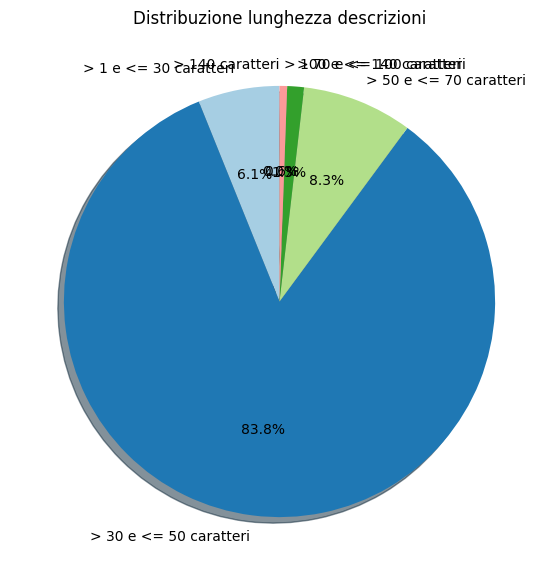

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_description_length(df):
    
    # Definizione delle categorie di lunghezza
    bins = [(1, 30), (31, 50), (51, 70), (71, 100), (101, 140), (141, float('inf'))]
    labels = ["> 1 e <= 30 caratteri", "> 30 e <= 50 caratteri", "> 50 e <= 70 caratteri", "> 70 e <= 100 caratteri", "> 100 e <= 140 caratteri", "> 140 caratteri"]
    
    total = len(df)
    counts = []
    percentages = []
    
    # Calcola il numero di record per ogni categoria
    for low, high in bins:
        count = len(df[(df['description'].str.len() > low) & (df['description'].str.len() <= high)])
        percentage = (count / total) * 100 if total > 0 else 0
        counts.append(count)
        percentages.append(percentage)
    
    # Stampa i risultati
    for label, count, percentage in zip(labels, counts, percentages):
        print(f"{label}: {count} record ({percentage:.2f}%)")
    
    if total == 0:
        print("Nessun record presente nel dataset. Diagramma a torta non generato.")
        return
    
    # Crea il diagramma a torta
    plt.figure(figsize=(7,7))
    plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=plt.cm.Paired.colors, shadow=True, startangle=90)
    plt.title('Distribuzione lunghezza descrizioni')
    plt.show()

analyze_description_length(dataframe)

## Analisi Date Scadenza

Primo record: 4102354800000000


Elaborazione record: 100%|██████████| 11114960/11114960 [11:38<00:00, 15922.28 record/s]



--- ANALISI CLUSTER TEMPORALI ---
Entro 10 anni: 937886 record (8.44%)
Tra 10 e 20 anni: 1350 record (0.01%)
  - 02/03/2036 1350
Tra 20 e 30 anni: 324 record (0.00%)
  - 31/12/2050 324
Oltre 30 anni: 10175400 record (91.55%)
  - 30/12/2099 283995
  - 31/12/2999 8942542
  - 31/12/2099 701335
  - 01/01/2090 236424
  - 01/01/2230 2873
  - 01/01/2260 4978
  - 29/12/2099 321
  - 31/12/4444 2136
  - 01/01/2099 715
  - 01/01/2290 81


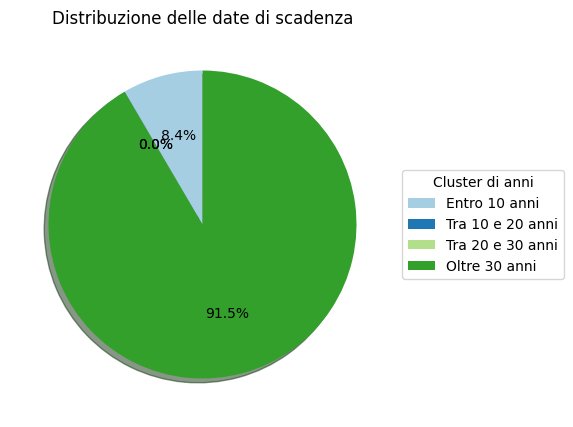


--- TOP 50 COMPANY CON SCADENZE OLTRE 30 ANNI ---
1. Comune di Cerro Maggiore: 3818923 record
2. EURORISTORAZIONE S.R.L.: 3207792 record
3. Comune di Busto Arsizio: 233196 record
4. Ministero delle Imprese e del Made in Italy: 169158 record
5. Sinergas S.p.A.: 168573 record
6. SERENISSIMA RISTORAZIONE S.p.A.: 94809 record
7. Scamar srl: 76891 record
8. Unione dei Comuni della Val di Merse: 64710 record
9. Azienda Unità Sanitaria Locale di Parma: 61623 record
10. CAMST SOC.COOP. A R.L.: 58532 record
11. SODEXO ITALIA SPA: 58009 record
12. EP S.p.A.: 54485 record
13. A. GAZZOLI & SOCI SRL: 54243 record
14. VIVENDA SPA: 47822 record
15. Comune di Campli: 47145 record
16. MINISTERO DELL'ECONOMIA E DELLE FINANZE: 46134 record
17. COMPASS GROUP ITALIA SPA: 44385 record
18. LA MEDITERRANEA SOC. COOP.: 40980 record
19. Azienda ULSS n.6 Euganea: 33001 record
20. ELIOR RISTORAZIONE S.P.A.: 31289 record
21. Azienda Unità Sanitaria di Bologna : 30643 record
22. Comune di Trepuzzi: 29935 record
23

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
from tqdm import tqdm
from collections import Counter

def analyze_due_dates(df):
    total = len(df)
    if total == 0:
        print("Nessun record presente nel dataset.")
        return
    
    # Debug: stampa il primo record se esiste
    if 'due_date' in df.columns and not df['due_date'].empty:
        print("Primo record:", df.iloc[0]['due_date'])
    
    # Definisci la data attuale
    today = datetime.now(timezone.utc)
    
    # Definisci i cluster di anni
    clusters = {
        "Entro 10 anni": 10,
        "Tra 10 e 20 anni": 20,
        "Tra 20 e 30 anni": 30,
        "Oltre 30 anni": float('inf')
    }
    
    # Conta i record per ciascun cluster e lista per le company "Oltre 30 anni"
    cluster_counts = {key: [] for key in clusters.keys()}
    over_30_companies = []

    # Iteriamo sul dataframe considerando sia la data che il nome dell'azienda
    # Filtriamo i record che hanno la data non nulla
    df_filtered = df.dropna(subset=['due_date'])

    for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Elaborazione record", unit=" record"):
        try: 
            date_val = row['due_date']
            company = row['company_name']
            
            # Converti da microsecondi a secondi
            timestamp_seconds = date_val / 1_000_000
            
            # Converte in datetime
            date_converted = datetime.fromtimestamp(timestamp_seconds, tz=timezone.utc)
            
            # Calcolo differenza in anni
            delta_years = (date_converted - today).total_seconds() / (365 * 24 * 3600)
            
            for cluster, years in clusters.items():
                if delta_years <= years:
                    cluster_counts[cluster].append(date_converted.strftime("%d/%m/%Y"))
                    
                    # Se il cluster è "Oltre 30 anni", salviamo la company
                    if cluster == "Oltre 30 anni":
                        over_30_companies.append(company)
                    break
        except Exception:
            continue
    
    # 1. Stampa i risultati dei cluster
    print("\n--- ANALISI CLUSTER TEMPORALI ---")
    for cluster, dates in cluster_counts.items():
        count = len(dates)
        print(f"{cluster}: {count} record ({count / total * 100:.2f}%)")
        
        if cluster != "Entro 10 anni" and count > 0:
            date_counts = Counter(dates)
            for date, freq in date_counts.items():
                print(f"  - {date} {freq}")
    
    # 2. Creazione grafico a torta
    plt.figure(figsize=(8, 5))
    counts = [len(dates) for dates in cluster_counts.values()]
    plt.pie(counts, autopct='%1.1f%%', colors=plt.cm.Paired.colors, shadow=True, startangle=90)
    plt.legend(cluster_counts.keys(), title="Cluster di anni", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.title("Distribuzione delle date di scadenza")
    plt.subplots_adjust(right=0.7)
    plt.show()

    # 3. Analisi Top 50 Company (Oltre 30 anni) - AGGIUNTA
    print("\n--- TOP 50 COMPANY CON SCADENZE OLTRE 30 ANNI ---")
    if over_30_companies:
        top_companies = Counter(over_30_companies).most_common(50)
        for i, (name, count) in enumerate(top_companies, 1):
            print(f"{i}. {name}: {count} record")
    else:
        print("Nessun record trovato con scadenza superiore a 30 anni.")

# Esempio di chiamata (assumendo che 'dataframe' sia definito)
analyze_due_dates(dataframe)